In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

In [3]:
import re
def extr_url_primer(urlpath):

    data = pd.read_html('https://fbref.com/es/comps/9/2019-2020/horario/Marcadores-y-partidos-de-2019-2020-Premier-League')
    data = data[0]
    for i in range(0,5):
        urlname = '202'+str(i)+'-'+'202'+str(i+1)+'/horario/Marcadores-y-partidos-de-202'+str(i)+'-202'+str(i+1)+'-Premier-League'
        url = urlpath + urlname 

        sesons_data = pd.read_html(url)
        sesons_data = sesons_data[0]
        data = pd.concat([data, sesons_data],axis=0)
    return data

def extraer_numero(cadena):
    numeros = re.findall(r'\b\d+\b', str(cadena))
    if numeros:
        return int(numeros[0])
    else:
        return None

In [29]:
urlpath = 'https://fbref.com/es/comps/9/'
data = extr_url_primer(urlpath)

In [30]:
data = data.dropna(subset='Árbitro')

In [31]:
data[['Goles Local', 'Goles Visitante']] = data['Marcador'].str.split('–', expand=True)
data = data.drop('Marcador', axis=1)
data['Goles Local'] = data['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data['Goles Visitante'] = data['Goles Visitante'].apply(extraer_numero).fillna(0).astype(int)
data = data.reset_index(drop=True)


In [11]:
data

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Notas,Goles Local,Goles Visitante
0,1.0,Vie,2019-08-09,20:00,Liverpool,1.8,0.9,Norwich City,53333.0,Anfield,Michael Oliver,Informe del partido,NaN,4,1
1,1.0,Sáb,2019-08-10,12:30,West Ham,1.1,3.2,Manchester City,59870.0,London Stadium,Mike Dean,Informe del partido,NaN,0,5
2,1.0,Sáb,2019-08-10,15:00,Burnley,0.9,1.2,Southampton,19784.0,Turf Moor,Graham Scott,Informe del partido,NaN,3,0
3,1.0,Sáb,2019-08-10,15:00,Watford,0.7,0.8,Brighton,20245.0,Vicarage Road Stadium,Craig Pawson,Informe del partido,NaN,0,3
4,1.0,Sáb,2019-08-10,15:00,Crystal Palace,0.9,1.1,Everton,25151.0,Selhurst Park,Jonathan Moss,Informe del partido,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2114,22.0,Dom,2025-01-19,14:00,Manchester Utd,1.5,1.9,Brighton,73758.0,Old Trafford,Peter Bankes,Informe del partido,NaN,1,3
2115,22.0,Dom,2025-01-19,14:00,Nott'ham Forest,1.8,0.9,Southampton,30180.0,The City Ground,Anthony Taylor,Informe del partido,NaN,3,2
2116,22.0,Dom,2025-01-19,14:00,Everton,1.8,1.1,Tottenham,39326.0,Goodison Park,Darren England,Informe del partido,NaN,3,2
2117,22.0,Dom,2025-01-19,16:30,Ipswich Town,0.5,3.0,Manchester City,29841.0,Portman Road Stadium,Samuel Barrott,Informe del partido,NaN,0,6


In [32]:
data['Goles Local'] = data['Goles Local'].apply(extraer_numero).fillna(0).astype(int)
data['Goles Visitante'] = data['Goles Visitante'].apply(extraer_numero).fillna(0).astype(int)

In [33]:
data = data.reset_index(drop=True)

In [18]:
data.to_csv('data_prime_league.csv')

In [25]:
data1 = pd.DataFrame({
    'Local':data['Local'],
    'Visitante':data['Visitante'],
    'Goles Local':data['Goles Local'],
    'Goles Visitante':data['Goles Visitante'],

})


# Calcular goles totales anotados y recibidos por cada equipo en casa y como visitante
home_stats = data1.groupby("Local").agg(
    GL=("Goles Local", "sum"), JL=("Local", "count")
).reset_index()

away_stats = data1.groupby("Visitante").agg(
    GV=("Goles Visitante", "sum"), JV=("Visitante", "count")
).reset_index()

home_stats_c = data.groupby("Local").agg(
    GLE=("Goles Visitante","sum"), JL=("Local", "count")
)
away_stats_c = data.groupby("Visitante").agg(
    GVE=("Goles Local","sum"), JV=("Visitante", "count")
)



# Calcular el promedio de goles anotados por partido
#home_stats_c["PGLE"] = home_stats_c["GLE"] / (home_stats["JL"])
#away_stats_c["PGVE"] = away_stats_c["GVE"] / (away_stats["JV"])
home_stats["PGL"] = home_stats["GL"] / (home_stats["JL"])
away_stats["PGV"] = away_stats["GV"] / (away_stats["JV"])
home_stats_c["PGLE"] = home_stats_c["GLE"] / home_stats_c["JL"] 
away_stats_c["PGVE"] = away_stats_c["GVE"] / away_stats_c["JV"] 

# Calcular los goles recibidos por cada equipo
home_conceded = data1.groupby("Local").agg(GEL=("Goles Visitante", "sum"))
away_conceded = data1.groupby("Visitante").agg(GEV=("Goles Local", "sum"))


# Combinar datos de promedio de goles anotados y recibidos

team_stats = home_stats.merge(home_conceded, on="Local").merge(
    away_stats.merge(away_conceded, on="Visitante"), left_on="Local", right_on="Visitante"
).merge(home_stats_c["PGLE"], on="Local").merge(away_stats_c["PGVE"], on="Visitante")

overall_avg_home_goals = home_stats["PGL"].mean()
 
# Renombrar columnas para claridad
team_stats = team_stats.rename(columns={"Local": "Team"}).drop(columns="Visitante")
team_stats['#PJ'] = home_stats["JL"] + away_stats["JV"]
team_stats['IAL'] = home_stats["PGL"] / overall_avg_home_goals

# Mostrar la tabla final
team_stats




,Team,GL,JL,PGL,GEL,GV,JV,PGV,GEV,PGLE,PGVE,#PJ,IAL
0,Arsenal,214,104,2.057692,109,176,106,1.660377,116,1.048077,1.094340,210,1.424525
1,Aston Villa,180,106,1.698113,148,125,104,1.201923,158,1.396226,1.519231,210,1.175591
2,Bournemouth,81,67,1.208955,93,82,68,1.205882,135,1.388060,1.985294,135,0.836951
3,Brentford,115,68,1.691176,94,87,67,1.298507,110,1.382353,1.641791,135,1.170789
4,Brighton,142,105,1.352381,133,136,105,1.295238,155,1.266667,1.476190,210,0.936244
5,Burnley,75,76,0.986842,118,76,76,1.000000,118,1.552632,1.552632,152,0.683184
6,Chelsea,179,105,1.704762,114,180,106,1.698113,145,1.085714,1.367925,211,1.180194
7,Crystal Palace,130,106,1.226415,135,110,104,1.057692,162,1.273585,1.557692,210,0.849038
8,Everton,122,104,1.173077,129,101,105,0.961905,174,1.240385,1.657143,209,0.812113
9,Fulham,89,68,1.308824,98,80,67,1.194030,99,1.441176,1.477612,135,0.906089


In [9]:
data1 = pd.DataFrame({
    'Local':data['Local'],
    'Visitante':data['Visitante'],
    'Goles Local':data['Goles Local'],
    'Goles Visitante':data['Goles Visitante'],

})

# Crear DataFrames base con estadísticas locales y visitantes
home_stats = data1.groupby("Local").agg(
    GL=("Goles Local", "sum"), JL=("Local", "count"), GLE=("Goles Visitante", "sum")
).reset_index()

away_stats = data1.groupby("Visitante").agg(
    GV=("Goles Visitante", "sum"), JV=("Visitante", "count"), GVE=("Goles Local", "sum")
).reset_index()

# Calcular promedios
home_stats["PGL"] = home_stats["GL"] / home_stats["JL"]  # Promedio goles local
home_stats["PGLE"] = home_stats["GLE"] / home_stats["JL"]  # Promedio goles en contra local

away_stats["PGV"] = away_stats["GV"] / away_stats["JV"]  # Promedio goles visitante
away_stats["PGVE"] = away_stats["GVE"] / away_stats["JV"]  # Promedio goles en contra visitante

# Calcular promedio general de goles locales
overall_avg_home_goals = home_stats["PGL"].mean()
overall_avg_home_goals_c = home_stats["PGLE"].mean()
overall_avg_away_goals = away_stats["PGV"].mean()
overall_avg_away_goals_c = away_stats["PGVE"].mean()

# Combinar las estadísticas locales y visitantes
team_stats = pd.merge(
    home_stats, away_stats, left_on="Local", right_on="Visitante", suffixes=("_Home", "_Away")
)

# Agregar columnas calculadas
team_stats = team_stats.rename(columns={"Local": "Team"}).drop(columns=["Visitante"])
team_stats["#PJ"] = team_stats["JL"] + team_stats["JV"]
team_stats["IAL"] = team_stats["PGL"] / overall_avg_home_goals
team_stats["IDL"] = team_stats["PGLE"] / overall_avg_home_goals_c
team_stats["IAV"] = team_stats["PGV"] / overall_avg_away_goals
team_stats["IDV"] = team_stats["PGVE"] / overall_avg_away_goals_c

# Organizar las columnas finales para que sean más legibles
team_stats = team_stats[
    [
        "Team","#PJ", "JL","JV",       # Equipo
        "GL", "GLE","GV", "GVE", # Goles Favor Encontra
        "PGL","PGLE", "PGV", "PGVE",  # promedios
        "IAL","IDL","IAV","IDV",    # Métricas adicionales
    ]
]

# Mostrar la tabla final
team_stats


,Team,#PJ,JL,JV,GL,GLE,GV,GVE,PGL,PGLE,PGV,PGVE,IAL,IDL,IAV,IDV
0,Arsenal,214,107,107,223,113,177,116,2.084112,1.056075,1.654206,1.084112,1.442843,0.730501,1.313917,0.650369
1,Aston Villa,214,107,107,181,149,128,162,1.691589,1.392523,1.196262,1.514019,1.171097,0.963227,0.950177,0.908274
2,Bournemouth,138,69,69,86,95,86,136,1.246377,1.376812,1.246377,1.971014,0.862874,0.952359,0.989983,1.182430
3,Brentford,138,70,68,115,98,89,111,1.642857,1.400000,1.308824,1.632353,1.137360,0.968399,1.039583,0.979264
4,Brighton,214,106,108,142,134,141,163,1.339623,1.264151,1.305556,1.509259,0.927429,0.874430,1.036988,0.905419
5,Burnley,152,76,76,75,118,76,118,0.986842,1.552632,1.000000,1.552632,0.683197,1.073976,0.794289,0.931438
6,Chelsea,214,107,107,184,116,181,148,1.719626,1.084112,1.691589,1.383178,1.190508,0.749895,1.343610,0.829781
7,Crystal Palace,214,107,107,131,137,116,162,1.224299,1.280374,1.084112,1.514019,0.847590,0.885652,0.861098,0.908274
8,Everton,213,107,106,129,132,102,174,1.205607,1.233645,0.962264,1.641509,0.834649,0.853328,0.764315,0.984757
9,Fulham,138,69,69,89,99,84,100,1.289855,1.434783,1.217391,1.449275,0.892974,0.992458,0.966960,0.869434


In [16]:
#Local Visitante
#IAL*IDV*promedio de goles
#IAV*IDL*promedio de goles

#Promedio de goles totales
pgt = (team_stats['GL'].sum()+team_stats['GV'].sum())/team_stats['#PJ'].sum()

#mu = Promedio Local
mu_local = team_stats['IAL'][6]*team_stats['IDV'][26]*pgt
mu_visitante = team_stats['IAV'][26]*team_stats['IDL'][6]*pgt

# tabla = [[float(poisson.pmf(i, mu_local)*poisson.pmf(j, mu_visitante)) for i in range(0,6) ],
#          [float(poisson.pmf(i, mu_local)*poisson.pmf(1, mu_visitante)) for i in range(0,6)],
#          [float(poisson.pmf(i, mu_local)*poisson.pmf(2, mu_visitante)) for i in range(0,6)],
#          [float(poisson.pmf(i, mu_local)*poisson.pmf(3, mu_visitante)) for i in range(0,6)],
#          [float(poisson.pmf(i, mu_local)*poisson.pmf(4, mu_visitante)) for i in range(0,6)],
#          [float(poisson.pmf(i, mu_local)*poisson.pmf(5, mu_visitante)) for i in range(0,6)],
#          ]

tabla = [[float(poisson.pmf(i, mu_local) * poisson.pmf(j, mu_visitante))*100 for j in range(6)] for i in range(6)]
# tabla_mas_2_5 = [
#     [tabla[i][j] for j in range(6) if j > 2]  # Filtrar columnas donde j > 2
#     for i in range(6) if i > 2  # Filtrar filas donde i > 2
# ]
# tabla_mas_2_5 = [
#     [tabla[i][j] for j in range(6) if j < 2]  # Filtrar columnas donde j > 2
#     for i in range(6) if i < 2  # Filtrar filas donde i > 2
# ]
lista_mas_2_5 = []
lista_menos_2_5 = []
lista_empate = []
lista_gana_local = []
lista_gana_visitante = []

for i in range(0,6):
    for j in range(0,6):
        if j+i>2:
            lista_mas_2_5.append(tabla[i][j])
        if j+i<=2:
            lista_menos_2_5.append(tabla[i][j])
        if j==i:
            lista_empate.append(tabla[i][j])
        if j>i:
            lista_gana_visitante.append(tabla[i][j])
        if i>j:
            lista_gana_local.append(tabla[i][j])

print('--------Probabilidades de Goles menor a 2.5 y mayor a 2.5-------------\n')
print('Más 2.5 Goles: ',sum(lista_mas_2_5))
print('Memos 2.5 Goles: ',sum(lista_menos_2_5),'\n')
print('--------------------Probabilidades Victoria empate--------------------\n')
print('Victoria del Local: ',sum(lista_gana_local))
print('Empate: ',sum(lista_empate))
print('Victoria del Visitante: ',sum(lista_gana_visitante))

--------Probabilidades de Goles menor a 2.5 y mayor a 2.5-------------

Más 2.5 Goles:  45.311788518339284
Memos 2.5 Goles:  54.009837667690505 

--------------------Probabilidades Victoria empate--------------------

Victoria del Local:  53.96592222315675
Empate:  24.774463162344635
Victoria del Visitante:  20.5812408005284


In [57]:
data["Fecha"] = pd.to_datetime(data["Fecha"])

data["Fecha"] = data["Fecha"].dt.year


In [35]:
data.groupby("Fecha").agg(
    GL=("Goles Local", "sum"), 
).reset_index()
data

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Notas,Goles Local,Goles Visitante
0,1.0,Vie,2019,20:00,Liverpool,1.8,0.9,Norwich City,53333.0,Anfield,Michael Oliver,Informe del partido,NaN,4,1
1,1.0,Sáb,2019,12:30,West Ham,1.1,3.2,Manchester City,59870.0,London Stadium,Mike Dean,Informe del partido,NaN,0,5
2,1.0,Sáb,2019,15:00,Burnley,0.9,1.2,Southampton,19784.0,Turf Moor,Graham Scott,Informe del partido,NaN,3,0
3,1.0,Sáb,2019,15:00,Watford,0.7,0.8,Brighton,20245.0,Vicarage Road Stadium,Craig Pawson,Informe del partido,NaN,0,3
4,1.0,Sáb,2019,15:00,Crystal Palace,0.9,1.1,Everton,25151.0,Selhurst Park,Jonathan Moss,Informe del partido,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,24.0,Sáb,2025,17:30,Wolves,1.6,0.4,Aston Villa,31385.0,Molineux Stadium,Andy Madley,Informe del partido,NaN,2,0
2135,24.0,Dom,2025,14:00,Brentford,2.1,0.8,Tottenham,17154.0,Gtech Community Stadium,Jarred Gillett,Informe del partido,NaN,0,2
2136,24.0,Dom,2025,14:00,Manchester Utd,1.1,2.6,Crystal Palace,73751.0,Old Trafford,John Brooks,Informe del partido,NaN,0,2
2137,24.0,Dom,2025,16:30,Arsenal,1.0,0.8,Manchester City,60355.0,Emirates Stadium,Peter Bankes,Informe del partido,NaN,5,1


In [36]:
data = data.drop(columns=['Notas'])
data

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante
0,1.0,Vie,2019,20:00,Liverpool,1.8,0.9,Norwich City,53333.0,Anfield,Michael Oliver,Informe del partido,4,1
1,1.0,Sáb,2019,12:30,West Ham,1.1,3.2,Manchester City,59870.0,London Stadium,Mike Dean,Informe del partido,0,5
2,1.0,Sáb,2019,15:00,Burnley,0.9,1.2,Southampton,19784.0,Turf Moor,Graham Scott,Informe del partido,3,0
3,1.0,Sáb,2019,15:00,Watford,0.7,0.8,Brighton,20245.0,Vicarage Road Stadium,Craig Pawson,Informe del partido,0,3
4,1.0,Sáb,2019,15:00,Crystal Palace,0.9,1.1,Everton,25151.0,Selhurst Park,Jonathan Moss,Informe del partido,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,24.0,Sáb,2025,17:30,Wolves,1.6,0.4,Aston Villa,31385.0,Molineux Stadium,Andy Madley,Informe del partido,2,0
2135,24.0,Dom,2025,14:00,Brentford,2.1,0.8,Tottenham,17154.0,Gtech Community Stadium,Jarred Gillett,Informe del partido,0,2
2136,24.0,Dom,2025,14:00,Manchester Utd,1.1,2.6,Crystal Palace,73751.0,Old Trafford,John Brooks,Informe del partido,0,2
2137,24.0,Dom,2025,16:30,Arsenal,1.0,0.8,Manchester City,60355.0,Emirates Stadium,Peter Bankes,Informe del partido,5,1


In [ ]:
data['Goles Totales'] = data['Goles Visitante']+data['Goles Local']


In [58]:
def goles_sem(sem,año):

    return data[(data['Sem.']==sem) & (data['Fecha']==año)]

In [65]:
goles_sem(25,np.int32(2020))

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
240,25.0,Sáb,2020,12:30,Leicester City,1.4,0.6,Chelsea,32186.0,King Power Stadium,Lee Mason,Informe del partido,2,2,4
241,25.0,Sáb,2020,15:00,West Ham,0.8,1.9,Brighton,59952.0,London Stadium,Michael Oliver,Informe del partido,3,3,6
242,25.0,Sáb,2020,15:00,Watford,0.9,2.2,Everton,21229.0,Vicarage Road Stadium,Craig Pawson,Informe del partido,2,3,5
243,25.0,Sáb,2020,15:00,Crystal Palace,0.8,0.7,Sheffield Utd,25170.0,Selhurst Park,Andy Madley,Informe del partido,0,1,1
244,25.0,Sáb,2020,15:00,Liverpool,3.2,0.8,Southampton,53291.0,Anfield,Kevin Friend,Informe del partido,4,0,4
245,25.0,Sáb,2020,15:00,Bournemouth,2.2,1.7,Aston Villa,10722.0,Vitality Stadium,Anthony Taylor,Informe del partido,2,1,3
246,25.0,Sáb,2020,15:00,Newcastle Utd,1.0,2.2,Norwich City,52204.0,St. James' Park,Martin Atkinson,Informe del partido,0,0,0
247,25.0,Sáb,2020,17:30,Manchester Utd,1.0,1.3,Wolves,73363.0,Old Trafford,Paul Tierney,Informe del partido,0,0,0
248,25.0,Dom,2020,14:00,Burnley,1.9,1.2,Arsenal,21048.0,Turf Moor,Chris Kavanagh,Informe del partido,0,0,0
249,25.0,Dom,2020,16:30,Tottenham,0.3,2.4,Manchester City,61022.0,Tottenham Hotspur Stadium,Mike Dean,Informe del partido,2,0,2


In [67]:
goles_sem(25,np.int32(2022))

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
984,25.0,Sáb,2022,12:30,Manchester Utd,2.1,0.8,Southampton,73084.0,Old Trafford,Stuart Attwell,Informe del partido,1,1,2
985,25.0,Sáb,2022,15:00,Everton,2.7,0.3,Leeds United,39150.0,Goodison Park,Graham Scott,Informe del partido,3,0,3
986,25.0,Sáb,2022,15:00,Brentford,1.6,0.3,Crystal Palace,16958.0,Brentford Community Stadium,Simon Hooper,Informe del partido,0,0,0
987,25.0,Sáb,2022,15:00,Watford,0.5,1.6,Brighton,20795.0,Vicarage Road Stadium,Jonathan Moss,Informe del partido,0,2,2
988,25.0,Sáb,2022,17:30,Norwich City,0.4,4.6,Manchester City,27010.0,Carrow Road,Andre Marriner,Informe del partido,0,4,4
989,25.0,Dom,2022,14:00,Newcastle Utd,0.5,0.6,Aston Villa,52207.0,St. James' Park,Craig Pawson,Informe del partido,1,0,1
990,25.0,Dom,2022,14:00,Burnley,1.5,1.7,Liverpool,19563.0,Turf Moor,Martin Atkinson,Informe del partido,0,1,1
991,25.0,Dom,2022,14:00,Tottenham,1.2,1.3,Wolves,56452.0,Tottenham Hotspur Stadium,Kevin Friend,Informe del partido,0,2,2
992,25.0,Dom,2022,16:30,Leicester City,1.4,1.1,West Ham,32061.0,King Power Stadium,Michael Oliver,Informe del partido,2,2,4
1077,25.0,Mié,2022,19:45,Chelsea,0.7,2.0,Arsenal,32249.0,Stamford Bridge,Jonathan Moss,Informe del partido,2,4,6


In [74]:
data=data
def filtro(data,local,visitante):
    data=data[(data['Local'].str.contains(local, case=False, na=False)) & (data['Visitante'].str.contains(visitante))]#filtro para los equipos
    data.loc[:, 'Fecha'] = pd.to_datetime(data['Fecha']).dt.date #se convierte a fecha el .loc es para no copias una columna
    data_sorted=data.sort_values(by='Fecha', ascending=True) #ordena por fecha de forma ascendente
    return data_sorted

In [75]:
filtro(data,'Bri','Chel')

/tmp/ipykernel_37633/3631086354.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[datetime.date(1970, 1, 1) datetime.date(1970, 1, 1)
 datetime.date(1970, 1, 1) datetime.date(1970, 1, 1)
 datetime.date(1970, 1, 1)]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  data.loc[:, 'Fecha'] = pd.to_datetime(data['Fecha']).dt.date #se convierte a fecha el .loc es para no copias una columna


,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
199,21.0,Mié,1970-01-01,12:30,Brighton,1.3,1.3,Chelsea,30559.0,The American Express Community Stadium,Stuart Attwell,Informe del partido,1,1,2
387,1.0,Lun,1970-01-01,20:15,Brighton,1.1,1.2,Chelsea,NaN,The American Express Community Stadium,Craig Pawson,Informe del partido,1,3,4
961,24.0,Mar,1970-01-01,20:00,Brighton,0.7,0.7,Chelsea,30880.0,The American Express Community Stadium,Kevin Friend,Informe del partido,1,1,2
1260,14.0,Sáb,1970-01-01,15:00,Brighton,2.4,1.4,Chelsea,31746.0,The American Express Community Stadium,Andy Madley,Informe del partido,4,1,5
1888,34.0,Mié,1970-01-01,19:45,Brighton,1.3,1.5,Chelsea,31555.0,The American Express Community Stadium,Michael Salisbury,Informe del partido,1,2,3


In [223]:
filtro('Tott','Wol')

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
1019,25.0,Dom,2022-02-13,14:00,Tottenham,1.2,1.3,Wolves,56452.0,Tottenham Hotspur Stadium,Kevin Friend,Informe del partido,0,2,2
400,3.0,Sáb,2022-08-20,12:30,Tottenham,1.7,0.7,Wolves,61298.0,Tottenham Hotspur Stadium,Simon Hooper,Informe del partido,1,0,1
240,25.0,Sáb,2024-02-17,15:00,Tottenham,1.6,1.8,Wolves,61532.0,Tottenham Hotspur Stadium,Anthony Taylor,Informe del partido,1,2,3


In [224]:
filtro('Crys','Sout')

,Sem.,Día,Fecha,Hora,Local,xG,xG.1,Visitante,Asistencia,Sedes,Árbitro,Informe del partido,Goles Local,Goles Visitante,Goles Totales
937,17.0,Mié,2021-12-15,19:30,Crystal Palace,1.2,0.6,Southampton,22861.0,Selhurst Park,Simon Hooper,Informe del partido,2,2,4
498,14.0,Sáb,2022-10-29,15:00,Crystal Palace,0.9,1.3,Southampton,25130.0,Selhurst Park,Michael Salisbury,Informe del partido,1,0,1


<BarContainer object of 100 artists>

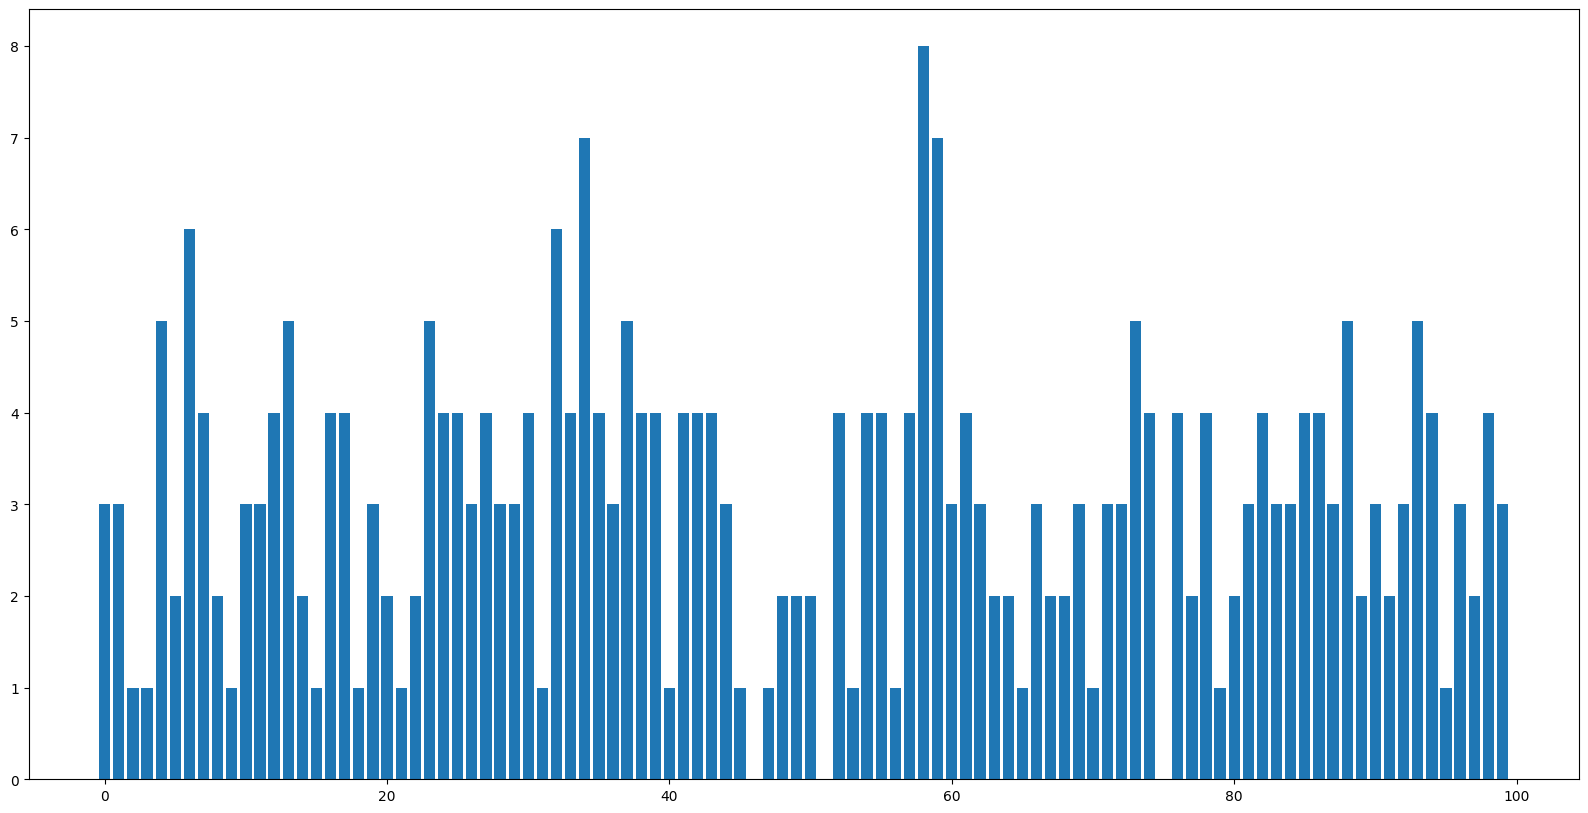

In [34]:
fig, ax = plt.subplots(figsize=(20,10))
ax.bar(np.arange(0,100),data3['Goles Totales'][:100])

In [46]:
goles = data3['Goles Totales'].values

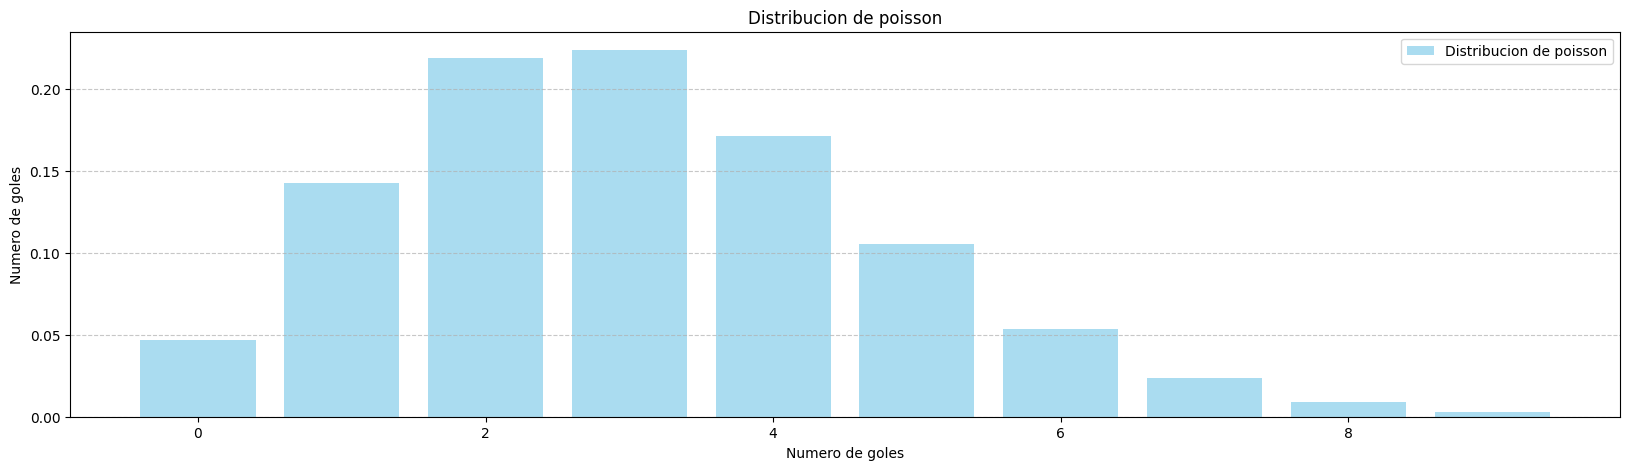

In [54]:
lambda_poisson = np.mean(goles)
x = np.arange(0, max(goles) + 1)
probabilidades = poisson.pmf(x, lambda_poisson)

fig, ax = plt.subplots(figsize=(20,5))
ax.bar(x, probabilidades, color='skyblue', alpha=0.7,label='Distribucion de poisson' )
ax.set_xlabel('Numero de goles')
ax.set_ylabel('Numero de goles')
ax.set_title(f'Distribucion de poisson')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)